# Thinking in LangGraph: email support agent

This notebook mirrors the customer support email workflow from the LangGraph docs page: https://docs.langchain.com/oss/python/langgraph/thinking-in-langgraph.

The LangGraph structure matches the page: state, error-handling patterns, nodes, `Command` routing, retry policy, checkpointer-backed `interrupt`, and the minimal human-review example. The intentional differences are the LLM provider setup and DeepSeek-compatible structured output: the docs use `ChatOpenAI(model="gpt-5-nano")`, while this notebook uses DeepSeek through the OpenAI-compatible `ChatOpenAI` client.

## Setup

Use the `langgraph-deepseek` conda environment as this notebook kernel.

If the Jupyter kernel has not been registered yet, run this once in your terminal:

```bash
conda run -n langgraph-deepseek python -m ipykernel install --user --name langgraph-deepseek --display-name langgraph-deepseek
```

If any dependency is missing, uncomment and run the install cell below.

In [6]:
# %pip install -U langgraph langchain langchain-openai

## Register the DeepSeek API key

You can set `DEEPSEEK_API_KEY` before starting Jupyter, or let this cell prompt for it and register it in the current notebook process.

In [7]:
import os
from getpass import getpass

if not os.environ.get("DEEPSEEK_API_KEY"):
    os.environ["DEEPSEEK_API_KEY"] = getpass("Enter your DeepSeek API key: ")

os.environ.setdefault("DEEPSEEK_BASE_URL", "https://api.deepseek.com")
os.environ.setdefault("DEEPSEEK_MODEL", "deepseek-v4-flash")

'deepseek-v4-flash'

In [8]:
from __future__ import annotations

from typing import Any, Literal, TypedDict

from langchain.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver, MemorySaver
from langgraph.errors import NodeError
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, RetryPolicy, interrupt

## LLM

The docs page initializes `ChatOpenAI(model="gpt-5-nano")`. DeepSeek exposes an OpenAI-compatible chat-completions API, so the only model-specific change is the `model`, `base_url`, and API key configuration.

DeepSeek's current model list includes `deepseek-v4-flash` and `deepseek-v4-pro`. This notebook defaults to `deepseek-v4-flash`; change `DEEPSEEK_MODEL` above if you want `deepseek-v4-pro`.

In [9]:
llm = ChatOpenAI(
    model=os.environ["DEEPSEEK_MODEL"],
    api_key=os.environ["DEEPSEEK_API_KEY"],
    base_url=os.environ["DEEPSEEK_BASE_URL"],
    temperature=0,
)

## State

This state schema follows the docs page. It stores raw data and leaves prompt formatting inside node functions.

In [10]:
class EmailClassification(TypedDict):
    intent: Literal["question", "bug", "billing", "feature", "complex"]
    urgency: Literal["low", "medium", "high", "critical"]
    topic: str
    summary: str


class EmailAgentState(TypedDict):
    # Raw email data
    email_content: str
    sender_email: str
    email_id: str

    # Classification result
    classification: EmailClassification | None

    # Raw search/API results
    search_results: list[str] | None
    customer_history: dict | None

    # Generated content
    draft_response: str | None
    messages: list[str] | None

## Error handling patterns

The docs page shows five error-handling patterns before the full email agent implementation:

- transient errors: add a `RetryPolicy` to a node
- LLM-recoverable errors: store the tool error in state and loop back
- user-fixable errors: pause with `interrupt()`
- unexpected errors: let them bubble up
- recoverable failure after retries: route through `error_handler`

The code below keeps those patterns explicit. A couple of examples use isolated demo workflows so the notebook can run top-to-bottom before the real email workflow is created later.

In [11]:
class SearchAPIError(Exception):
    pass


class ToolError(Exception):
    pass


class State(TypedDict, total=False):
    tool_call: str
    tool_result: str
    customer_id: str
    customer_history: dict[str, Any]
    search_results: list[str]
    draft_response: str
    status: str


class EmailService:
    def send(self, draft_response: str) -> None:
        print(f"Sending via email service: {draft_response[:100]}...")


email_service = EmailService()


def run_tool(tool_call: str) -> str:
    if tool_call == "fail":
        raise ToolError("The requested tool failed")
    return f"tool result for {tool_call}"


def fetch_customer_history(customer_id: str) -> dict[str, Any]:
    return {"customer_id": customer_id, "tier": "standard", "open_tickets": 0}


def charge_payment(state: State) -> dict[str, str]:
    raise ConnectionError("payment service unavailable")


def finalize(state: State) -> dict[str, str]:
    return {"status": state.get("status", "finalized")}

In [12]:
# Transient errors: add a retry policy to automatically retry network issues and rate limits.
def search_documentation_retry_example(state: State) -> dict[str, list[str]]:
    return {"search_results": ["example search result"]}


retry_example_workflow = StateGraph(State)
retry_example_workflow.add_node(
    "search_documentation",
    search_documentation_retry_example,
    retry_policy=RetryPolicy(max_attempts=3, initial_interval=1.0),
)


# LLM-recoverable errors: store the error in state and loop back.
def execute_tool(state: State) -> Command[Literal["agent", "execute_tool"]]:
    try:
        result = run_tool(state['tool_call'])
        return Command(update={"tool_result": result}, goto="agent")
    except ToolError as e:
        # Let the LLM see what went wrong and try again
        return Command(
            update={"tool_result": f"Tool error: {str(e)}"},
            goto="agent"
        )


# User-fixable errors: pause and collect information from the user.
def lookup_customer_history(state: State) -> Command[Literal["draft_response"]]:
    if not state.get('customer_id'):
        user_input = interrupt(
            {
                "message": "Customer ID needed",
                "request": "Please provide the customer's account ID to look up their subscription history",
            }
        )
        return Command(
            update={"customer_id": user_input['customer_id']},
            goto="lookup_customer_history"
        )

    # Now proceed with the lookup
    customer_data = fetch_customer_history(state['customer_id'])
    return Command(update={"customer_history": customer_data}, goto="draft_response")


# Unexpected errors: do not catch what you cannot handle.
def send_reply(state: EmailAgentState):
    try:
        email_service.send(state["draft_response"])
    except Exception:
        raise  # Surface unexpected errors


# Recoverable failure after retries: run a recovery function that routes to compensation.
def payment_error_handler(state: State, error: NodeError) -> Command:
    return Command(
        update={"status": f"compensated: {error.error}"},
        goto="finalize",
    )


compensation_workflow = StateGraph(State)
compensation_workflow.add_node(
    "charge_payment",
    charge_payment,
    retry_policy=RetryPolicy(max_attempts=3, retry_on=ConnectionError),
    error_handler=payment_error_handler,
)
compensation_workflow.add_node("finalize", finalize)

## Email agent nodes

These nodes follow the page's code. The only DeepSeek-specific adjustment is `method="json_mode"` for structured classification, because DeepSeek's documented JSON output mode uses `response_format={"type": "json_object"}` and requires the prompt to mention JSON.

In [ ]:
def read_email(state: EmailAgentState) -> dict:
    """Extract and parse email content"""
    # In production, this would connect to your email service
    return {
        "messages": [HumanMessage(content=f"Processing email: {state['email_content']}")]
    }


def classify_intent(
    state: EmailAgentState,
) -> Command[Literal["search_documentation", "human_review", "draft_response", "bug_tracking"]]:
    """Use LLM to classify email intent and urgency, then route accordingly"""

    # Create structured LLM that returns EmailClassification dict
    structured_llm = llm.with_structured_output(EmailClassification, method="json_mode")

    # Format the prompt on-demand, not stored in state
    classification_prompt = f"""
    Analyze this customer email and classify it.

    Email: {state['email_content']}
    From: {state['sender_email']}

    Return json with exactly these fields:
    {{
      "intent": "question | bug | billing | feature | complex",
      "urgency": "low | medium | high | critical",
      "topic": "short topic string",
      "summary": "brief summary"
    }}
    """

    # Get structured response directly as dict
    classification = structured_llm.invoke(classification_prompt)
    print("LLM classification:", classification)
    # Determine next node based on classification
    if classification["intent"] == "billing" or classification["urgency"] == "critical":
        goto = "human_review"
    elif classification["intent"] in ["question", "feature"]:
        goto = "search_documentation"
    elif classification["intent"] == "bug":
        goto = "bug_tracking"
    else:
        goto = "draft_response"

    # Store classification as a single dict in state
    return Command(
        update={"classification": classification},
        goto=goto,
    )

### Search and tracking nodes

In [14]:
def search_documentation(state: EmailAgentState) -> Command[Literal["draft_response"]]:
    """Search knowledge base for relevant information"""
    # Build search query from classification
    classification = state.get("classification", {})
    query = f"{classification.get('intent', '')} {classification.get('topic', '')}"

    try:
        # Implement your search logic here
        # Store raw search results, not formatted text
        search_results = [
            "Reset password via Settings > Security > Change Password",
            "Password must be at least 12 characters",
            "Include uppercase, lowercase, numbers, and symbols",
        ]
    except SearchAPIError as e:
        # For recoverable search errors, store error and continue
        search_results = [f"Search temporarily unavailable: {str(e)}"]

    return Command(
        update={"search_results": search_results},
        goto="draft_response",
    )


def bug_tracking(state: EmailAgentState) -> Command[Literal["draft_response"]]:
    """Create or update bug tracking ticket"""

    # Create ticket in your bug tracking system
    ticket_id = "BUG-12345"
    return Command(
        update={
            "search_results": [f"Bug ticket {ticket_id} created"],
            "current_step": "bug_tracked",
        },
        goto="draft_response",
    )

### Response nodes

In [15]:
def draft_response(state: EmailAgentState) -> Command[Literal["human_review", "send_reply"]]:
    """Generate response using context and route based on quality"""

    classification = state.get("classification", {})

    # Format context from raw state data on-demand
    context_sections = []

    if state.get("search_results"):
        # Format search results for the prompt
        formatted_docs = "\n".join([f"- {doc}" for doc in state["search_results"]])
        context_sections.append(f"Relevant documentation:\n{formatted_docs}")

    if state.get("customer_history"):
        # Format customer data for the prompt
        context_sections.append(
            f"Customer tier: {state['customer_history'].get('tier', 'standard')}"
        )

    # Build the prompt with formatted context
    draft_prompt = f"""
    Draft a response to this customer email:
    {state['email_content']}

    Email intent: {classification.get('intent', 'unknown')}
    Urgency level: {classification.get('urgency', 'medium')}
    {chr(10).join(context_sections)}

    Guidelines:
    - Be professional and helpful
    - Address their specific concern
    - Use the provided documentation when relevant
    """

    response = llm.invoke(draft_prompt)

    # Determine if human review needed based on urgency and intent
    needs_review = (
        classification.get("urgency") in ["high", "critical"]
        or classification.get("intent") == "complex"
    )

    # Route to appropriate next node
    goto = "human_review" if needs_review else "send_reply"

    return Command(
        update={"draft_response": response.content},
        goto=goto,
    )


def human_review(state: EmailAgentState) -> Command[Literal["send_reply", END]]:
    """Pause for human review using interrupt and route based on decision"""

    classification = state.get("classification", {})

    # interrupt() must come first - any code before it will re-run on resume
    human_decision = interrupt(
        {
            "email_id": state.get("email_id", ""),
            "original_email": state.get("email_content", ""),
            "draft_response": state.get("draft_response", ""),
            "urgency": classification.get("urgency"),
            "intent": classification.get("intent"),
            "action": "Please review and approve/edit this response",
        }
    )

    # Now process the human's decision
    if human_decision.get("approved"):
        return Command(
            update={
                "draft_response": human_decision.get(
                    "edited_response",
                    state.get("draft_response", ""),
                )
            },
            goto="send_reply",
        )
    else:
        # Rejection means human will handle directly
        return Command(update={}, goto=END)


def send_reply(state: EmailAgentState) -> dict:
    """Send the email response"""
    # Integrate with email service
    print(f"Sending reply: {state['draft_response'][:100]}...")
    return {}

## Wire it together

The graph structure is minimal because routing happens inside the nodes through `Command` objects.

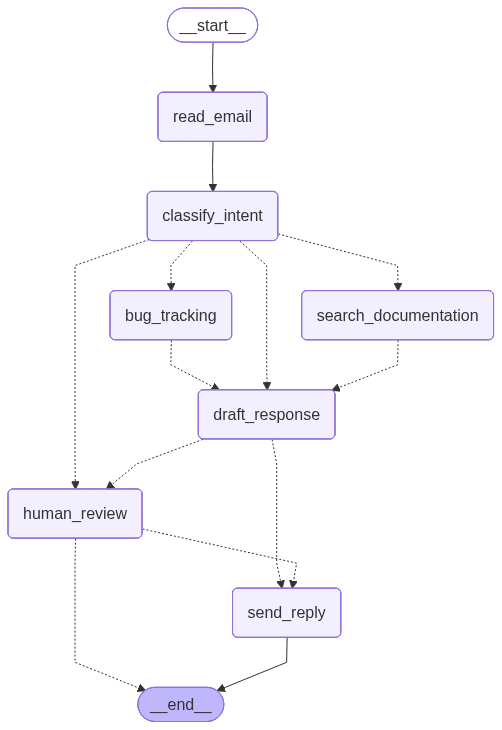

In [16]:
# Create the graph
workflow = StateGraph(EmailAgentState)

# Add nodes with appropriate error handling
workflow.add_node("read_email", read_email)
workflow.add_node("classify_intent", classify_intent)

# Add retry policy for nodes that might have transient failures
workflow.add_node(
    "search_documentation",
    search_documentation,
    retry_policy=RetryPolicy(max_attempts=3),
)
workflow.add_node("bug_tracking", bug_tracking)
workflow.add_node("draft_response", draft_response)
workflow.add_node("human_review", human_review)
workflow.add_node("send_reply", send_reply)

# Add only the essential edges
workflow.add_edge(START, "read_email")
workflow.add_edge("read_email", "classify_intent")
workflow.add_edge("send_reply", END)

# Compile with checkpointer for persistence.
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)
app

## Try the full email agent

This invokes the DeepSeek-backed classifier. A billing or critical email routes to `human_review`, which pauses with an interrupt and can be resumed with `Command(resume=...)`.

In [17]:
initial_email = {
    "email_content": "I was charged twice for my subscription! This is urgent!",
    "sender_email": "customer@example.com",
    "email_id": "email_123",
    "classification": None,
    "search_results": None,
    "customer_history": None,
    "draft_response": None,
    "messages": None,
}

config = {"configurable": {"thread_id": "email_123"}}
result = app.invoke(initial_email, config, version="v2")
print(f"interrupts: {result.interrupts}")
result.value

interrupts: (Interrupt(value={'email_id': 'email_123', 'original_email': 'I was charged twice for my subscription! This is urgent!', 'draft_response': None, 'urgency': 'high', 'intent': 'billing', 'action': 'Please review and approve/edit this response'}, id='d7b02d7c108d753e67f3be76c2c8fd61'),)


{'email_content': 'I was charged twice for my subscription! This is urgent!',
 'sender_email': 'customer@example.com',
 'email_id': 'email_123',
 'classification': {'intent': 'billing',
  'urgency': 'high',
  'topic': 'double charge',
  'summary': 'Customer reports being charged twice for subscription, requests urgent resolution.'},
 'search_results': None,
 'customer_history': None,
 'draft_response': None,
 'messages': [HumanMessage(content='Processing email: I was charged twice for my subscription! This is urgent!', additional_kwargs={}, response_metadata={})]}

In [18]:
human_response = Command(
    resume={
        "approved": True,
        "edited_response": "We sincerely apologize for the double charge. I've initiated an immediate refund review.",
    }
)

final_result = app.invoke(human_response, config, version="v2")
print("Email sent successfully!")
final_result.value

Sending reply: We sincerely apologize for the double charge. I've initiated an immediate refund review....
Email sent successfully!


{'email_content': 'I was charged twice for my subscription! This is urgent!',
 'sender_email': 'customer@example.com',
 'email_id': 'email_123',
 'classification': {'intent': 'billing',
  'urgency': 'high',
  'topic': 'double charge',
  'summary': 'Customer reports being charged twice for subscription, requests urgent resolution.'},
 'search_results': None,
 'customer_history': None,
 'draft_response': "We sincerely apologize for the double charge. I've initiated an immediate refund review.",
 'messages': [HumanMessage(content='Processing email: I was charged twice for my subscription! This is urgent!', additional_kwargs={}, response_metadata={})]}

## Minimal interrupt example

This is the small human-review example from the docs page.

In [19]:
class EmailState(TypedDict):
    email_content: str
    response_text: str | None


def human_review_node(state: EmailState):
    interrupt(
        {
            "approved": False,
            "edited_response": state.get("response_text") or "",
        }
    )
    return {"response_text": "placeholder"}


review_app = (
    StateGraph(EmailState)
    .add_node("human_review", human_review_node)
    .add_edge(START, "human_review")
    .add_edge("human_review", END)
    .compile(checkpointer=InMemorySaver())
)

initial_state = {
    "email_content": "I was charged twice for my subscription! This is urgent!",
    "response_text": "Draft response",
}

# Run with a thread_id for persistence
review_config = {"configurable": {"thread_id": "customer_123"}}
review_result = review_app.invoke(initial_state, review_config, version="v2")

# The graph will pause at human_review
print(f"human review interrupt:{review_result.interrupts}")

review_human_response = Command(
    resume={
        "approved": True,
        "edited_response": "We sincerely apologize for the double charge. I've initiated an immediate refund...",
    }
)

# Resume execution
review_final_result = review_app.invoke(review_human_response, review_config, version="v2")
print("Email sent successfully!")
review_final_result.value

human review interrupt:(Interrupt(value={'approved': False, 'edited_response': 'Draft response'}, id='ee5754e778533b61bfc4485a3f2ce711'),)
Email sent successfully!


{'email_content': 'I was charged twice for my subscription! This is urgent!',
 'response_text': 'placeholder'}